In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import skimage as ski
import bm3d
import importlib
import os
import modules.optics as op
import seaborn as sns

0.0 1.0


,Filter,PSNR,SSIM
0,Noisy,25.361678,0.200135
1,wiener,23.233943,0.129194
2,tv,25.361720,0.200136
3,bm3d,25.361583,0.200131
4,rl,23.260223,0.129902
5,w_rl,21.497047,0.090149
6,rl_w,20.662179,0.075396
7,w_w,20.635614,0.074989
8,rl_rl,21.537181,0.090907


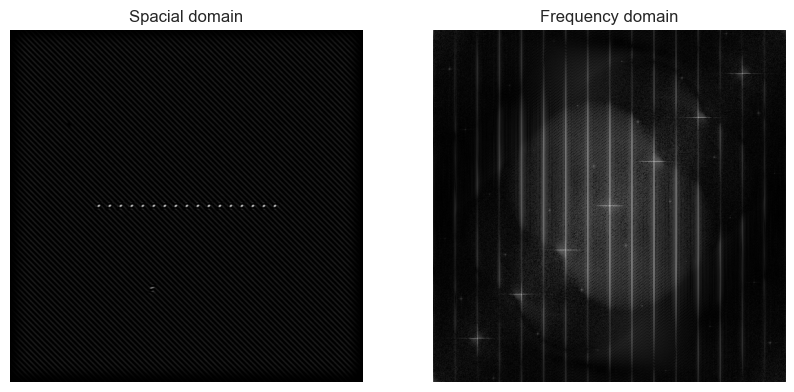

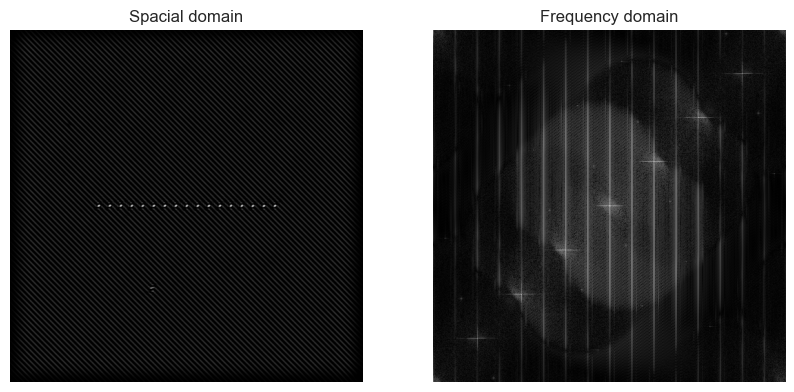

In [24]:
# Load the clean reference image
center_dot_gt = ski.io.imread('source_images\center_dot.tif')
dotted_gt = ski.io.imread('source_images\dotted_line.tif')
metric = center_dot_gt

# SIM results
sim_results = ski.io.imread('output_images\point_source\dotted_line\mix_0_1_percent_sim.tif')
sim_results = op.normalize(sim_results)
print(np.min(sim_results), np.max(sim_results))

noisy_sim = sim_results[0]
filter_names = ['wiener', 'tv', 'bm3d', 'rl', 'w_rl', 'rl_w', 'w_w', 'rl_rl']

# Data storage
results = []
noisy_psnr = ski.metrics.peak_signal_noise_ratio(metric, sim_results[0])
noisy_ssim = ski.metrics.structural_similarity(metric, sim_results[0], data_range=1)
results.append(['Noisy', noisy_psnr, noisy_ssim])

for i in range(1, len(filter_names)+1):
    psnr_value = ski.metrics.peak_signal_noise_ratio(metric, sim_results[i])
    ssim_value = ski.metrics.structural_similarity(metric, sim_results[i], data_range=1)

    results.append([filter_names[i-1], psnr_value, ssim_value])

df = pd.DataFrame(results, columns=['Filter', 'PSNR', 'SSIM'])
display(df)

op.display_fourier(noisy_sim)
op.display_fourier(sim_results[5])

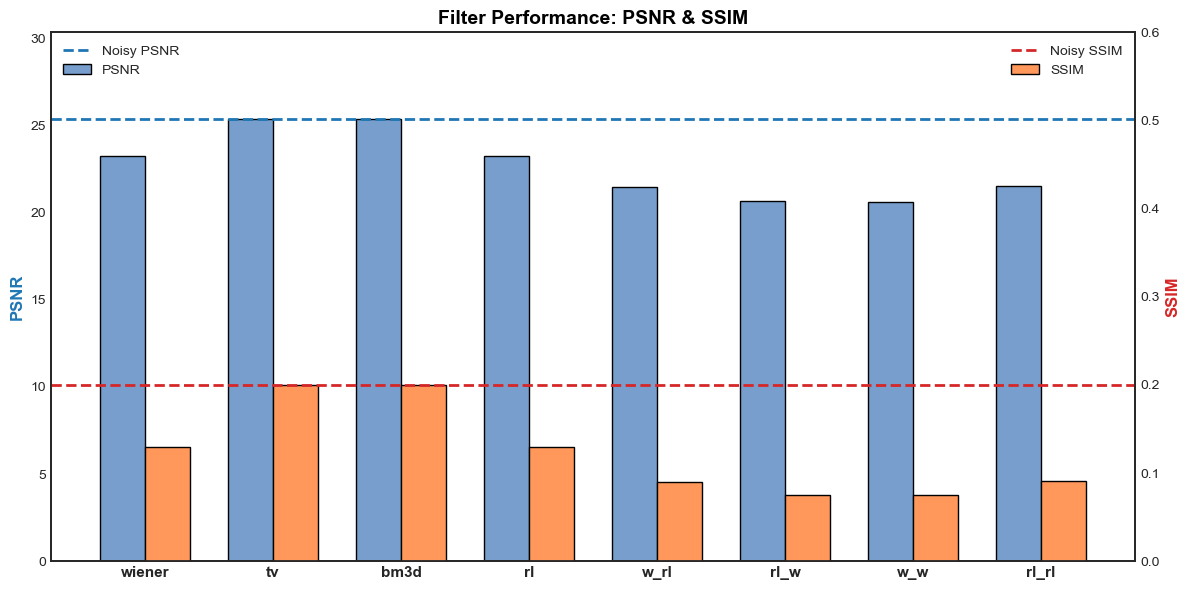

In [25]:

# Define custom colors
psnr_color = "#779ECC"  # Modern blue
ssim_color = "#FF985A"  # Modern orange
noisy_psnr_color = "#1f77b4"  # Darker blue for noisy threshold
noisy_ssim_color = "#d62728"  # Dark red for noisy threshold
# Set plot style
plt.style.use("seaborn-v0_8-white")

# Exclude noisy from x-axis labels
filters = df['Filter'].unique()
filters = [f for f in filters if f != "Noisy"]

x = np.arange(len(filters))  # X positions for each filter
bar_width = 0.35  # Width of the bars

fig, ax1 = plt.subplots(figsize=(12, 6))

# Create twin y-axis
ax2 = ax1.twinx()

# PSNR Bars (Left Y-axis)
ax1.bar(x - bar_width / 2, df[df['Filter'] != 'Noisy']['PSNR'], width=bar_width, color=psnr_color, label='PSNR', edgecolor="black")

# SSIM Bars (Right Y-axis)
ax2.bar(x + bar_width / 2, df[df['Filter'] != 'Noisy']['SSIM'], width=bar_width, color=ssim_color, label='SSIM', edgecolor="black")

# Reference lines for Noisy
noisy_psnr = df[df['Filter'] == 'Noisy']['PSNR'].values[0]
noisy_ssim = df[df['Filter'] == 'Noisy']['SSIM'].values[0]
ax1.axhline(y=noisy_psnr, color=noisy_psnr_color, linestyle='dashed', linewidth=2, label='Noisy PSNR')
ax2.axhline(y=noisy_ssim, color=noisy_ssim_color, linestyle='dashed', linewidth=2, label='Noisy SSIM')

# Y-axis settings
ax1.set_ylabel('PSNR', color=noisy_psnr_color, fontsize=12, fontweight='bold')
ax1.set_ylim(0, df['PSNR'].max() + 5)

ax2.set_ylabel('SSIM', color=noisy_ssim_color, fontsize=12, fontweight='bold')
ax2.set_ylim(0, 0.6)

# X-axis settings
ax1.set_xticks(x)
ax1.set_xticklabels(filters, fontsize=11, fontweight='bold')

# Titles and legends
plt.title('Filter Performance: PSNR & SSIM', fontsize=14, fontweight='bold', color="black")
ax1.legend(loc='upper left', fontsize=10)
ax2.legend(loc='upper right', fontsize=10)

# Improve layout
plt.tight_layout()

# Show plot
plt.show()
